In [2]:
!lscpu

Architecture:                aarch64
  CPU op-mode(s):            64-bit
  Byte Order:                Little Endian
CPU(s):                      14
  On-line CPU(s) list:       0-13
Vendor ID:                   Apple
  Model:                     0
  Thread(s) per core:        1
  Core(s) per cluster:       14
  Socket(s):                 -
  Cluster(s):                1
  Stepping:                  0x0
  BogoMIPS:                  48.00
  Flags:                     fp asimd evtstrm aes pmull sha1 sha2 crc32 atomics 
                             fphp asimdhp cpuid asimdrdm jscvt fcma lrcpc dcpop 
                             sha3 asimddp sha512 asimdfhm dit uscat ilrcpc flagm
                              sb paca pacg dcpodp flagm2 frint bf16 afp
Vulnerabilities:             
  Gather data sampling:      Not affected
  Indirect target selection: Not affected
  Itlb multihit:             Not affected
  L1tf:                      Not affected
  Mds:                       Not affected
  Me

In [3]:
# iterate over all files in the directory use modern python path library
from pathlib import Path
import subprocess

is_runnable = lambda f: f.is_file() and f.stem.startswith("loop_") and subprocess.run([f],
                                                                                      capture_output=True).returncode == 0

targets = ["c-scalar", "scalar", "autovec-sve", "autovec-sve2", "neon", "sve", "sve2", "sve2p1", "sve-intrinsics"]
targets = ["c-scalar", "scalar", "neon"]

loops_map = {}
for target in targets:
    loops_dir = Path.home() / f"simd-loops/build/{target}/standalone/bin"
    loops = [int(f.stem[len("loop_"):]) for f in loops_dir.iterdir() if is_runnable(f)]
    loops.sort()
    loops_map[target] = loops


# find the intersection of all loops
common_loops = set(loops_map[targets[0]])
for target in targets[1:]:
    common_loops.intersection_update(loops_map[target])
print(sorted(common_loops))

c-scalar [1, 2, 3, 4, 5, 6, 8, 9, 10, 12, 19, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 33, 34, 35, 36, 37, 38, 40, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 120, 121, 122, 123, 124, 126, 127, 128, 130, 135, 136, 137, 201, 202, 204, 205, 206, 207, 208, 210, 211, 212, 215, 216, 217, 218, 219, 220, 221, 222, 223, 231, 245]
scalar [1, 2, 3, 4, 5, 6, 8, 9, 10, 19, 22, 23, 25, 26, 27, 28, 29, 31, 32, 33, 34, 36, 37, 102, 109, 110, 111, 112, 113]
neon [1, 2, 3, 4, 5, 6, 8, 9, 10, 19, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 33, 34, 35, 36, 37, 38, 40, 101, 102, 103, 105, 108, 109, 110, 111, 112, 113, 114, 126, 130, 137, 201, 202, 204, 205, 206, 210, 211, 212, 215, 216, 217, 218, 219, 220, 221, 222, 223, 231, 245]
[1, 2, 3, 4, 5, 6, 8, 9, 10, 19, 22, 23, 25, 26, 27, 28, 29, 31, 32, 33, 34, 36, 37, 102, 109, 110, 111, 112, 113]


In [180]:
import subprocess
import json

num_warmup = 1
num_runs = 2
loop_iterations = 10_000_000
# loop_iterations = 10

results = []
for loop_id in sorted(common_loops):
    # print(f"Loop {loop_id}:")
    hyperfine_cmd = ['hyperfine',
                     # '--ignore-failure',
                     '--show-output', '--export-json', 'result.json', f'--warmup={num_warmup}',
                     f'--runs={num_runs}']
    for target in targets:
        hyperfine_cmd.extend(['-n', target, f'./build/{target}/bin/simd_loops -k {loop_id} -n {loop_iterations}'])
    subprocess.run(hyperfine_cmd, cwd=Path.home() / "simd-loops", text=True, check=True, capture_output=True)

    result = json.loads((Path.home() / "simd-loops" / "result.json").read_text())
    result = result['results']
    target_results = {record['command']: record['mean'] for record in result}
    target_results = [target_results[target] for target in targets]
    results.append((loop_id, target_results))

In [181]:
import pandas as pd

df = []
for loop_id, target_results in results:
    df.append([loop_id] + target_results)

df = pd.DataFrame(df, columns=['loop_id'] + targets)

# make every coulmn relative to the first column
for target in targets[1:]:
    df[target] = df[target] / df[targets[0]]
    df[target] *= 100

df

,loop_id,c-scalar,scalar,neon
0,1,77.104151,14.971703,7.146898
1,2,29.297284,38.116550,15.412631
2,3,37.970119,15.009798,14.717744
3,4,14.659052,38.243695,38.372206
4,5,12.605266,100.570150,103.396389
5,6,4.064681,110.435576,110.377947
6,8,56.511130,85.387545,83.348417
7,9,6.994217,100.591534,101.164014
8,10,28.963340,89.390413,88.422917
9,19,25.651038,96.706258,99.505748


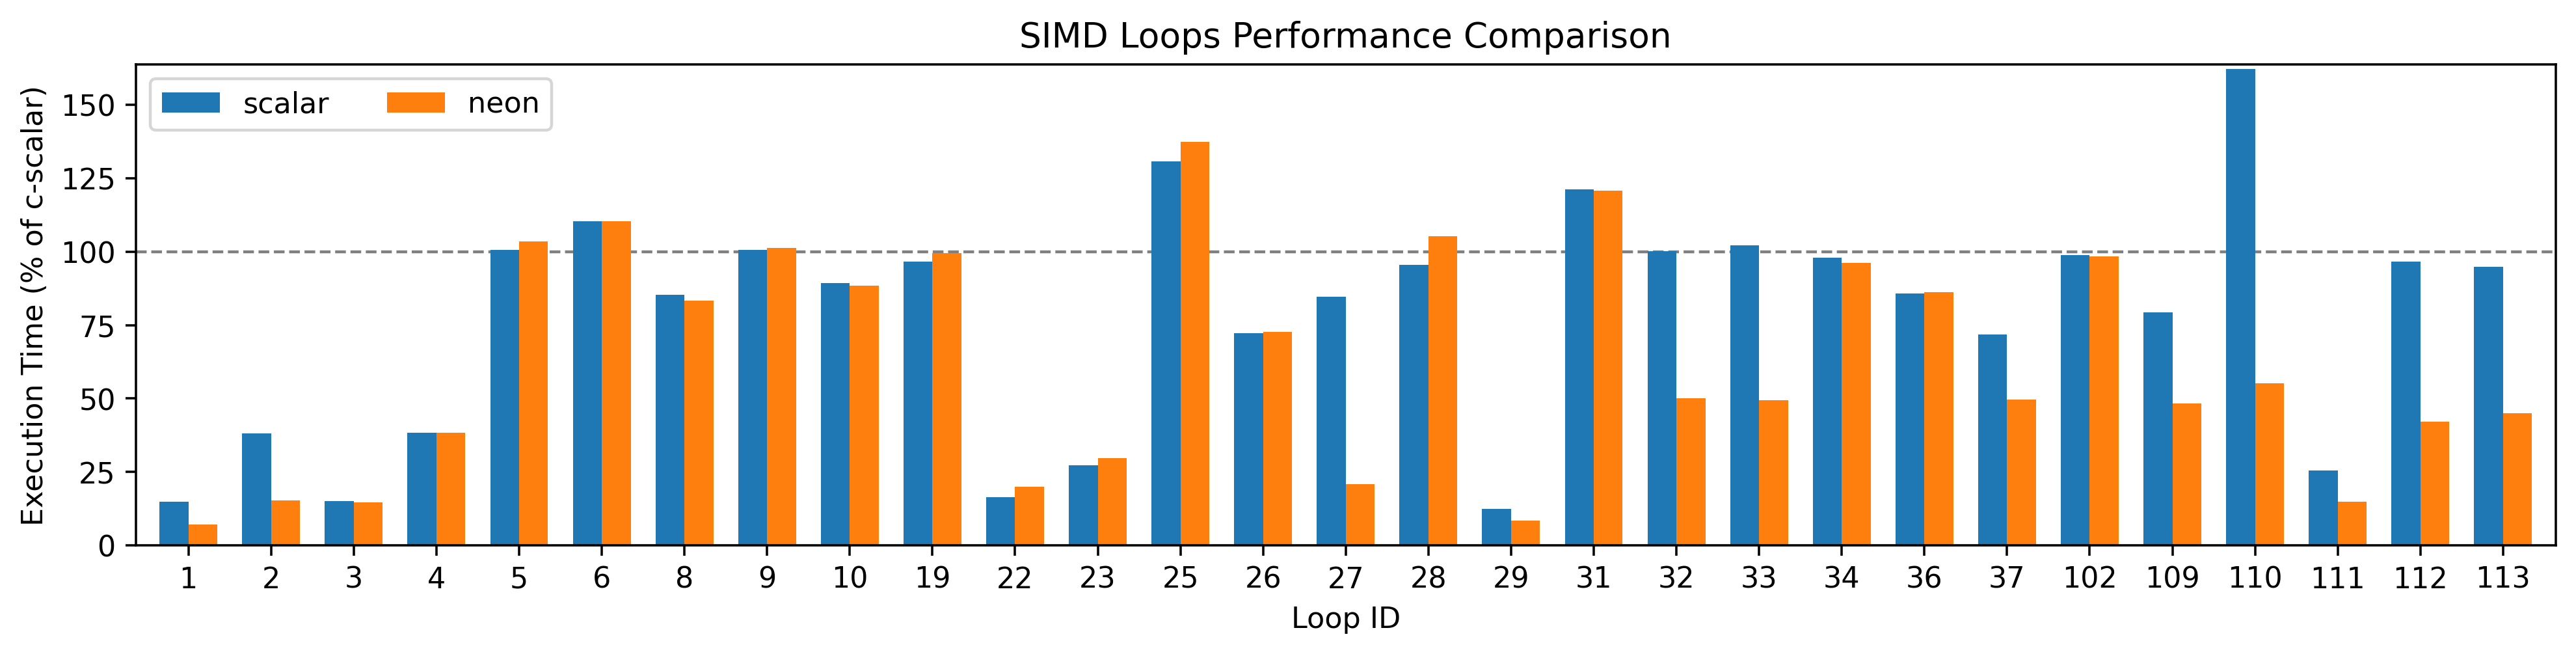

In [183]:
# plot a bar chart of the results using matplotlib
# for each loop id, plot 2 bars, one for scalar and one for neon all relative to c-scalar

import matplotlib.pyplot as plt

x = df['loop_id'].astype(str)
xs = range(len(x))

width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(15, 3), dpi=320)

for i, target in enumerate(targets[1:]):
    ax.bar([xi + (i - .5) * width for xi in xs], df[target], width, label=target)

ax.set_ylabel('Execution Time (% of c-scalar)')
ax.set_xticks(xs)
ax.set_xticklabels(x)
# x is loop id
ax.set_xlabel('Loop ID')
ax.set_title('SIMD Loops Performance Comparison')
ax.legend(ncol=2)

# margin x is zero
ax.margins(0.01)

# draw a vertical line at y=100
ax.axhline(y=100, color='gray', linestyle='--', linewidth=1, zorder=0)

# save to png
plt.savefig('results.png', dpi=320, bbox_inches='tight')

plt.show()